# Appended VTK XML in the native C++ core

VTP/VTS/VTR/VTI now share VTU's raw/base64 appended decoder. This dependency-free example constructs a UInt64-framed ImageData temperature array without using any mesh writer, reads it through the registry and renders it as SVG. Both encodings give the same mesh. Selective reads suppress data, not connectivity. Writers remain inline; multiple pieces are still a follow-up. See the Python counterpart `28_vtk_xml_appended.ipynb` for VTK-produced compressed files in all four formats.

In [1]:
#define MESHIOPLUSPLUS_IMPLEMENTATION
#include "../../src/single_include/meshioplusplus/meshioplusplus.hpp"
#include "mio_notebook.hpp"
#include <iostream>
using namespace meshioplusplus;
using namespace mio_nb;

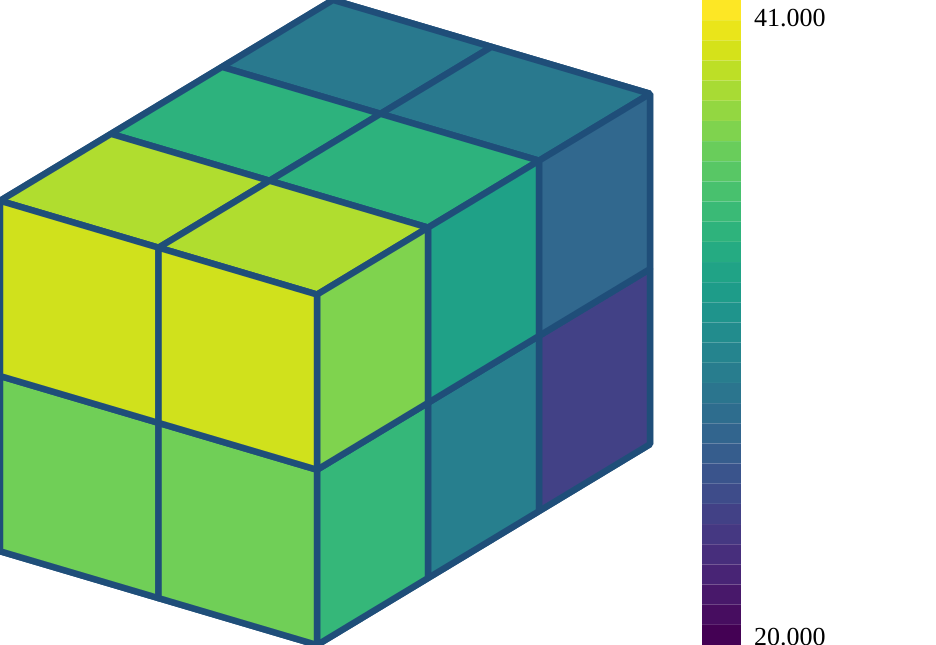

36 points, 12 hexahedra
points_only: 1 connectivity block, 0 fields


In [2]:
std::vector<unsigned char> framed;
auto pack_le = [](std::uint64_t value, int width) {
    for (int i = 0; i < width; ++i) framed.push_back(static_cast<unsigned char>(value >> (8*i)));
};
pack_le(36*4, 8); // UInt64 byte-count header, then 36 Int32 temperatures
for (int k = 0; k < 3; ++k)
    for (int j = 0; j < 3; ++j)
        for (int i = 0; i < 4; ++i) pack_le(20 + 5*i + 3*k, 4);
std::string prefix = R"(<VTKFile type='ImageData' byte_order='LittleEndian' header_type='UInt64'>
<ImageData WholeExtent='0 3 0 2 0 2' Origin='0 0 0' Spacing='1 1 1'>
<Piece Extent='0 3 0 2 0 2'><PointData>
<DataArray type='Int32' Name='temperature' format='appended' offset='0'/>
</PointData></Piece></ImageData><AppendedData encoding=)";
auto raw_path = std::filesystem::temp_directory_path() / "mio_nb_appended_raw.vti";
auto b64_path = std::filesystem::temp_directory_path() / "mio_nb_appended_b64.vti";
{
    auto out = detail::make_classic_ofstream(raw_path, std::ios::binary);
    out << prefix << "'raw'>_";
    out.write(reinterpret_cast<const char*>(framed.data()), framed.size());
    out << "</AppendedData></VTKFile>";
}
{
    auto out = detail::make_classic_ofstream(b64_path);
    out << prefix << "'base64'>_" << detail::b64encode(framed.data(), framed.size()) << "</AppendedData></VTKFile>";
}
auto mesh = registry_read(raw_path.string(), "vti", {});
auto encoded = registry_read(b64_path.string(), "vti", {});
auto summary = registry_read_metadata(raw_path.string(), "vti", {});
std::cout << summary.mNumPoints << " points, " << summary.NumCells() << " hexahedra\n";
if (encoded.NumPoints() != mesh.NumPoints() || detail::read_int(encoded.PointData("temperature"), 35) != 41)
    throw std::runtime_error("base64 framing differs");
ReadOptions opts;
opts.mPointsOnly = true;
auto geometry = registry_read(raw_path.string(), "vti", opts);
std::cout << "points_only: " << geometry.NumCellBlocks() << " connectivity block, " << geometry.PointDataNames().size() << " fields\n";
std::filesystem::remove(raw_path);
std::filesystem::remove(b64_path);
xcpp::display(render(mesh, "temperature", "viridis", true, 20, 41, 35, 25, 650));